# MLP MNIST 

Multi-layer perceptron for MNIST.


Device: cpu
Saved figure: mlp_architecture.png


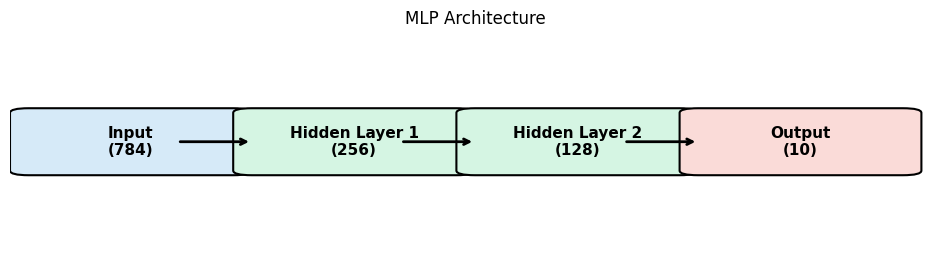

MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)
Trainable parameters: 235146
Epoch 1/8 | Train Loss 0.4328 Acc 0.8762 | Val Loss 0.2303 Acc 0.9336
Epoch 2/8 | Train Loss 0.1727 Acc 0.9486 | Val Loss 0.1544 Acc 0.9564
Epoch 3/8 | Train Loss 0.1168 Acc 0.9643 | Val Loss 0.1320 Acc 0.9614
Epoch 4/8 | Train Loss 0.0836 Acc 0.9740 | Val Loss 0.1163 Acc 0.9662
Epoch 5/8 | Train Loss 0.0634 Acc 0.9803 | Val Loss 0.1131 Acc 0.9698
Epoch 6/8 | Train Loss 0.0482 Acc 0.9854 | Val Loss 0.1085 Acc 0.9698
Epoch 7/8 | Train Loss 0.0370 Acc 0.9884 | Val Loss 0.1027 Acc 0.9721
Epoch 8/8 | Train Loss 0.0281 Acc 0.9918 | Val Loss 0.1114 Acc 0.9712
Final Val Accuracy: 0.9711904761904762
Final Val F1: 0.9709656164715886
Saved figure: mlp_curves.png


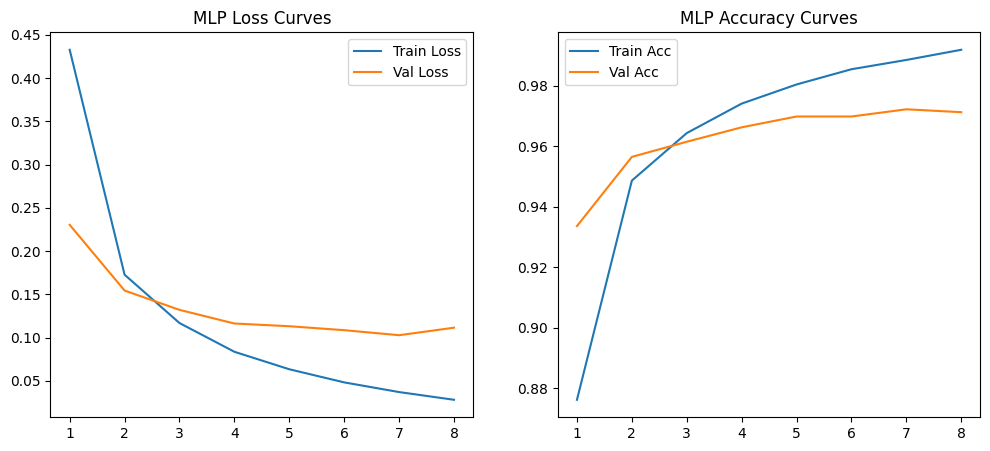

Saved figure: mlp_confusion.png


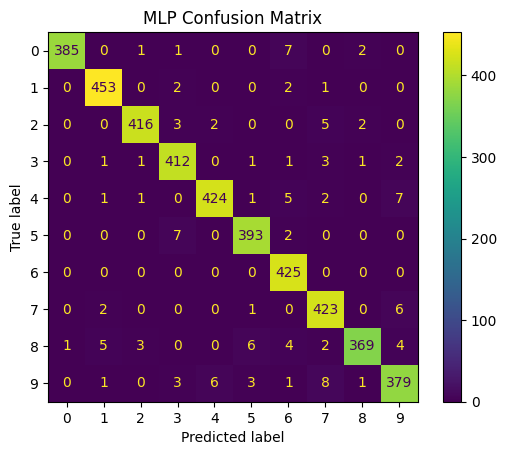

Saved figure: mlp_weights.png


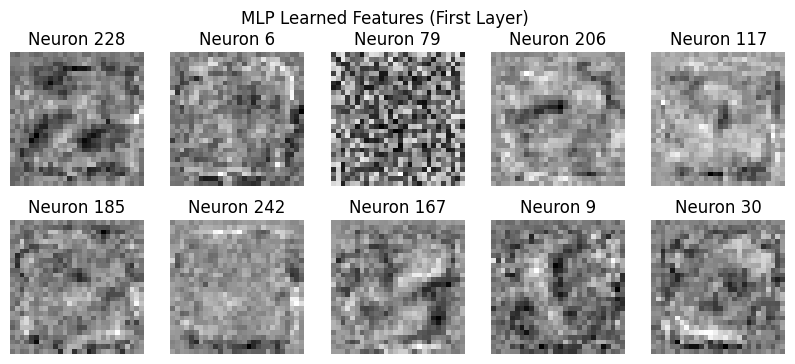

[Full Train] Epoch 1/8 Loss 0.0342
[Full Train] Epoch 2/8 Loss 0.0249
[Full Train] Epoch 3/8 Loss 0.0182
[Full Train] Epoch 4/8 Loss 0.0160
[Full Train] Epoch 5/8 Loss 0.0126
[Full Train] Epoch 6/8 Loss 0.0116
[Full Train] Epoch 7/8 Loss 0.0089
[Full Train] Epoch 8/8 Loss 0.0101
Saved submission_mlp.csv
{'Model': 'MLP', 'Val Accuracy': np.float64(0.9711904761904762), 'Val F1': 0.9709656164715886, 'Train Time (s)': 17.81108069419861, 'Params': 235146, 'Kaggle Score': 0.0}
Saved metrics JSON: mlp_results.json
Saved metrics CSV: mlp_results.csv


In [1]:
# =========================
# MLP Notebook (Digit Recognizer)
# =========================

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Auto-save figures and metrics
# -----------------------------
from pathlib import Path
import json

OUTPUT_DIR = Path('.')
FIGURE_QUEUE = ['mlp_architecture.png', 'mlp_curves.png', 'mlp_confusion.png', 'mlp_weights.png'].copy()

_original_show = plt.show

def _json_safe(obj):
    try:
        import numpy as _np
        if isinstance(obj, (_np.integer, )):
            return int(obj)
        if isinstance(obj, (_np.floating, )):
            return float(obj)
        if isinstance(obj, _np.ndarray):
            return obj.tolist()
    except Exception:
        pass
    if isinstance(obj, Path):
        return str(obj)
    return obj


def _auto_save_show(*args, **kwargs):
    fig = plt.gcf()
    if FIGURE_QUEUE:
        fname = OUTPUT_DIR / FIGURE_QUEUE.pop(0)
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f'Saved figure: {fname}')
    return _original_show(*args, **kwargs)

plt.show = _auto_save_show


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# Find dataset automatically
# -----------------------------
def find_digit_recognizer_paths():
    base="/kaggle/input"
    for root,_,files in os.walk(base):
        if "train.csv" in files and "test.csv" in files:
            return os.path.join(root,"train.csv"),os.path.join(root,"test.csv")
    raise FileNotFoundError("Digit Recognizer dataset not found")

TRAIN_PATH,TEST_PATH=find_digit_recognizer_paths()

train_df=pd.read_csv(TRAIN_PATH)
test_df=pd.read_csv(TEST_PATH)

y_all=train_df["label"].values.astype(np.int64)
X_all=train_df.drop(columns=["label"]).values.astype(np.float32)/255.0
X_test=test_df.values.astype(np.float32)/255.0

# -----------------------------
# Dataset
# -----------------------------
class MNISTDataset(Dataset):
    def __init__(self,X,y=None):
        self.X=X
        self.y=y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):

        x=torch.tensor(self.X[idx],dtype=torch.float32)

        if self.y is None:
            return x

        y=torch.tensor(self.y[idx],dtype=torch.long)

        return x,y


full_ds=MNISTDataset(X_all,y_all)

val_size=int(0.1*len(full_ds))
train_size=len(full_ds)-val_size

generator=torch.Generator().manual_seed(SEED)
train_ds,val_ds=random_split(full_ds,[train_size,val_size], generator=generator)

BATCH_SIZE=128

train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

# -----------------------------
# MLP Architecture Diagram
# -----------------------------
from matplotlib.patches import FancyBboxPatch

fig,ax=plt.subplots(figsize=(12,3))

def draw_box(text,x,color):

    box=FancyBboxPatch((x,0.4),0.22,0.25,
                       boxstyle="round,pad=0.02",
                       linewidth=1.5,
                       edgecolor="black",
                       facecolor=color)

    ax.add_patch(box)

    ax.text(x+0.11,0.525,text,
            ha="center",
            va="center",
            fontsize=11,
            weight="bold")

draw_box("Input\n(784)",0.02,"#D6EAF8")
draw_box("Hidden Layer 1\n(256)",0.26,"#D5F5E3")
draw_box("Hidden Layer 2\n(128)",0.50,"#D5F5E3")
draw_box("Output\n(10)",0.74,"#FADBD8")

ax.annotate("",xy=(0.26,0.525),xytext=(0.18,0.525),arrowprops=dict(arrowstyle="->",linewidth=2))
ax.annotate("",xy=(0.50,0.525),xytext=(0.42,0.525),arrowprops=dict(arrowstyle="->",linewidth=2))
ax.annotate("",xy=(0.74,0.525),xytext=(0.66,0.525),arrowprops=dict(arrowstyle="->",linewidth=2))

ax.axis("off")
ax.set_title("MLP Architecture")

plt.show()

# -----------------------------
# Model
# -----------------------------
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1=nn.Linear(784,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,10)

        self.relu=nn.ReLU()

    def forward(self,x):

        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)

        return x


model=MLP().to(device)

print(model)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Trainable parameters:",count_params(model))

# -----------------------------
# Training Setup
# -----------------------------
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-3)

EPOCHS=8

def eval_acc_f1(model,loader):

    model.eval()

    all_preds=[]
    all_true=[]

    with torch.no_grad():

        for x,y in loader:

            x,y=x.to(device),y.to(device)

            logits=model(x)

            preds=torch.argmax(logits,dim=1)

            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())

    all_preds=np.concatenate(all_preds)
    all_true=np.concatenate(all_true)

    acc=(all_preds==all_true).mean()
    f1=f1_score(all_true,all_preds,average="macro")

    return acc,f1,all_true,all_preds


# -----------------------------
# Training Loop
# -----------------------------
train_losses=[]
val_losses=[]
train_accs=[]
val_accs=[]

start=time.time()

for epoch in range(1,EPOCHS+1):

    model.train()

    running_loss=0
    correct=0
    total=0

    for x,y in train_loader:

        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()

        logits=model(x)

        loss=criterion(logits,y)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

        preds=torch.argmax(logits,dim=1)

        correct+=(preds==y).sum().item()
        total+=y.size(0)

    tr_loss=running_loss/len(train_loader)
    tr_acc=correct/total

    model.eval()

    vloss=0
    vcorrect=0
    vtotal=0

    with torch.no_grad():

        for x,y in val_loader:

            x,y=x.to(device),y.to(device)

            logits=model(x)

            loss=criterion(logits,y)

            vloss+=loss.item()

            preds=torch.argmax(logits,dim=1)

            vcorrect+=(preds==y).sum().item()
            vtotal+=y.size(0)

    va_loss=vloss/len(val_loader)
    va_acc=vcorrect/vtotal

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")

train_time=time.time()-start

final_acc,final_f1,y_true,y_pred=eval_acc_f1(model,val_loader)

print("Final Val Accuracy:",final_acc)
print("Final Val F1:",final_f1)

# -----------------------------
# Curves
# -----------------------------
epochs=range(1,EPOCHS+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,train_losses,label="Train Loss")
plt.plot(epochs,val_losses,label="Val Loss")
plt.legend()
plt.title("MLP Loss Curves")

plt.subplot(1,2,2)
plt.plot(epochs,train_accs,label="Train Acc")
plt.plot(epochs,val_accs,label="Val Acc")
plt.legend()
plt.title("MLP Accuracy Curves")

plt.show()

# -----------------------------
# Confusion Matrix
# -----------------------------
cm=confusion_matrix(y_true,y_pred)

disp=ConfusionMatrixDisplay(cm)
disp.plot(values_format="d")

plt.title("MLP Confusion Matrix")
plt.show()


# -----------------------------
# Learned Features (MLP)
# -----------------------------
W1 = model.fc1.weight.detach().cpu().numpy()  # shape (256,784)

# pick 10 random neurons
idx = np.random.choice(W1.shape[0],10,replace=False)

plt.figure(figsize=(10,4))

for i,k in enumerate(idx):
    
    plt.subplot(2,5,i+1)
    plt.imshow(W1[k].reshape(28,28), cmap="gray")
    plt.title(f"Neuron {k}")
    plt.axis("off")

plt.suptitle("MLP Learned Features (First Layer)")
plt.show()

# -----------------------------
# Train on full dataset (MLP)
# -----------------------------
full_loader = DataLoader(MNISTDataset(X_all, y_all), batch_size=BATCH_SIZE, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

model.train()

for epoch in range(1, EPOCHS + 1):

    running = 0

    for x, y in full_loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        loss = criterion(model(x), y)

        loss.backward()

        optimizer.step()

        running += loss.item()

    print(f"[Full Train] Epoch {epoch}/{EPOCHS} Loss {running/len(full_loader):.4f}")

# -----------------------------
# Submission
# -----------------------------
test_loader=DataLoader(MNISTDataset(X_test),batch_size=BATCH_SIZE)

model.eval()

preds_all=[]

with torch.no_grad():

    for x in test_loader:

        x=x.to(device)

        preds=torch.argmax(model(x),dim=1)

        preds_all.append(preds.cpu().numpy())

preds_all=np.concatenate(preds_all)

submission=pd.DataFrame({
"ImageId":np.arange(1,len(preds_all)+1),
"Label":preds_all
})

submission.to_csv("submission_mlp.csv",index=False)

print("Saved submission_mlp.csv")

# -----------------------------
# Save Results
# -----------------------------
mlp_results={
"Model":"MLP",
"Val Accuracy":final_acc,
"Val F1":final_f1,
"Train Time (s)":train_time,
"Params":count_params(model),
"Kaggle Score": 0.0
}

print(mlp_results)


# -----------------------------
# Export metrics for report
# -----------------------------
try:
    _results = mlp_results
    import pandas as pd
    _results_path_json = OUTPUT_DIR / 'mlp_results.json'
    _results_path_csv = OUTPUT_DIR / 'mlp_results.csv'
    with open(_results_path_json, 'w') as f:
        json.dump({k: _json_safe(v) for k, v in _results.items()}, f, indent=2)
    pd.DataFrame([{k: _json_safe(v) for k, v in _results.items()}]).to_csv(_results_path_csv, index=False)
    print(f'Saved metrics JSON: {_results_path_json}')
    print(f'Saved metrics CSV: {_results_path_csv}')
except Exception as exc:
    print('Could not export metrics automatically:', exc)
